# Otimizacao de Rotas Medicas com Algoritmo Genetico

Notebook ponta a ponta do desafio: carrega o catalogo de pontos, calcula distancias (Haversine), avalia cromossomos, roda o algoritmo genetico, visualiza a convergencia e a rota, compara com baselines nos experimentos E1/E2/E3 e gera um relatorio em linguagem natural.

As secoes 3 e 4 usam cromossomos fixos apenas para demonstrar a funcao `evaluate()`; a partir da secao 6 o algoritmo genetico encontra a rota de fato.

Configuracao inicial para importar os modulos do projeto.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DEFAULT_CONFIG
from src.data_loader import get_hospitals, get_origin, get_supply_stations, load_points
from src.distance import build_distance_matrix
from src.fitness import evaluate

## 1. Carregar catalogo de pontos

O catalogo contem a origem, os hospitais obrigatorios e os pontos de abastecimento.

In [2]:
points = load_points(PROJECT_ROOT / "data" / "pontos_entrega.csv")

origin = get_origin(points)
hospitals = get_hospitals(points)
supply_stations = get_supply_stations(points)

print(f"Origem: {origin.idx} - {origin.name}")
print(f"Hospitais: {len(hospitals)}")
print(f"Abastecimentos: {len(supply_stations)}")
print(f"Total de pontos: {len(points)}")

for point in points:
    print(f"{point.idx:>3} | {point.type:<8} | {point.name:<24} | prioridade={point.priority or '-':<5} | demanda={point.demand}")

Origem: 0 - Hospital Central
Hospitais: 12
Abastecimentos: 3
Total de pontos: 16
  0 | origin   | Hospital Central         | prioridade=-     | demanda=0
  1 | hospital | Unidade Hospitalar A     | prioridade=ALTA  | demanda=30
  2 | hospital | Unidade Hospitalar B     | prioridade=MEDIA | demanda=20
  3 | hospital | Unidade Hospitalar C     | prioridade=BAIXA | demanda=10
  4 | hospital | Unidade Hospitalar D     | prioridade=ALTA  | demanda=25
  5 | hospital | Unidade Hospitalar E     | prioridade=MEDIA | demanda=35
  6 | hospital | Unidade Hospitalar F     | prioridade=BAIXA | demanda=15
  7 | hospital | Unidade Hospitalar G     | prioridade=ALTA  | demanda=40
  8 | hospital | Unidade Hospitalar H     | prioridade=MEDIA | demanda=20
  9 | hospital | Unidade Hospitalar I     | prioridade=BAIXA | demanda=15
 10 | hospital | Unidade Hospitalar J     | prioridade=ALTA  | demanda=30
 11 | hospital | Unidade Hospitalar K     | prioridade=MEDIA | demanda=25
 12 | hospital | Unidade Hospita

## 2. Calcular matriz de distancias

A matriz guarda a distancia entre cada par de pontos. Ela nao gera rotas nem testa combinacoes; apenas evita recalcular distancias.

In [3]:
distance_matrix = build_distance_matrix(points)

print(f"Pares calculados: {len(distance_matrix)}")
print(f"Exemplo 0 -> 1: {distance_matrix[(0, 1)]:.4f}")
print(f"Exemplo 1 -> 0: {distance_matrix[(1, 0)]:.4f}")

Pares calculados: 256
Exemplo 0 -> 1: 1.2579
Exemplo 1 -> 0: 1.2579


## 3. Avaliar um cromossomo manual

Nesta etapa, o cromossomo e informado manualmente apenas para demonstrar a funcao de avaliacao. A capacidade inicial do veiculo vem de `DEFAULT_CONFIG.vehicle_capacity`.

In [4]:
chromosome = [3, 1, 5, 2, 4]

result = evaluate(chromosome, points, distance_matrix, DEFAULT_CONFIG)

print(f"Capacidade inicial do veiculo: {DEFAULT_CONFIG.vehicle_capacity}")
print(f"Peso da prioridade: {DEFAULT_CONFIG.lambda_priority}")
print(f"Peso do abastecimento: {DEFAULT_CONFIG.lambda_supply}")
print()
print(f"Cromossomo: {result.chromosome}")
print(f"Rota decodificada: {result.decoded_route}")
print(f"Distancia total: {result.total_distance:.4f}")
print(f"Penalidade de prioridade: {result.priority_penalty:.2f}")
print(f"Penalidade de abastecimento: {result.supply_penalty:.2f}")
print(f"Reabastecimentos: {result.resupply_count}")
print(f"Fitness: {result.fitness:.2f}")
print(f"Valido: {result.is_valid}")
print(f"Erros: {result.errors}")

Capacidade inicial do veiculo: 100
Peso da prioridade: 5.0
Peso do abastecimento: 10.0

Cromossomo: [3, 1, 5, 2, 4]
Rota decodificada: [0, 3, 1, 5, 2, 101, 4, 0]
Distancia total: 26.3260
Penalidade de prioridade: 36.00
Penalidade de abastecimento: 1.00
Reabastecimentos: 1
Fitness: 216.33
Valido: True
Erros: []


## 4. Exemplo com abastecimento

Neste exemplo, a capacidade do veiculo e 100. As demandas dos hospitais escolhidos sao 40, 30 e 35. Depois das duas primeiras entregas, restam 30 de carga; como o proximo hospital demanda 35, o decoder insere um abastecimento antes da entrega.

In [5]:
chromosome_with_resupply = [7, 10, 5]
result_with_resupply = evaluate(chromosome_with_resupply, points, distance_matrix, DEFAULT_CONFIG)

for hospital_idx in chromosome_with_resupply:
    hospital = next(point for point in points if point.idx == hospital_idx)
    print(f"Hospital {hospital.idx}: demanda={hospital.demand}")

print()
print(f"Carga inicial: {DEFAULT_CONFIG.vehicle_capacity}")
print(f"Cromossomo: {result_with_resupply.chromosome}")
print(f"Rota decodificada: {result_with_resupply.decoded_route}")
print(f"Reabastecimentos: {result_with_resupply.resupply_count}")
print(f"Penalidade de abastecimento: {result_with_resupply.supply_penalty:.2f}")
print(f"Fitness: {result_with_resupply.fitness:.2f}")

Hospital 7: demanda=40
Hospital 10: demanda=30
Hospital 5: demanda=35

Carga inicial: 100
Cromossomo: [7, 10, 5]
Rota decodificada: [0, 7, 10, 101, 5, 0]
Reabastecimentos: 1
Penalidade de abastecimento: 1.00
Fitness: 102.70


## 5. Uso esperado

A funcao principal entregue e:

```python
result = evaluate(chromosome, points, distance_matrix, config)
```

Ela recebe um cromossomo pronto e devolve a rota decodificada, a distancia, as penalidades e a fitness.

## 6. Visualizacao da evolucao do algoritmo genetico

As celulas abaixo executam o algoritmo genetico completo e visualizam o resultado:

- a **curva de convergencia** da fitness (melhor e media por geracao);
- o **mapa da melhor rota** encontrada, com origem, hospitais (cor e tamanho por prioridade) e abastecimentos diferenciados.

Os graficos aparecem inline; nao e preciso salvar em arquivo dentro do notebook.

In [6]:
from dataclasses import replace

from src.genetic_algorithm import run_genetic_algorithm
from src.visualization import plot_fitness_evolution, plot_route_map

# reaproveita points e distance_matrix carregados nas secoes anteriores
config = replace(DEFAULT_CONFIG, seed=42)  # seed fixa deixa o resultado reproduzivel
evolution = run_genetic_algorithm(points, distance_matrix, config)
best = evolution.best

print(f"Geracoes: {evolution.generations}")
print(f"Melhor cromossomo: {best.chromosome}")
print(f"Melhor rota: {best.decoded_route}")
print(f"Distancia total: {best.total_distance:.2f} km")
print(f"Reabastecimentos: {best.resupply_count}")
print(f"Melhor fitness: {best.fitness:.2f}")

Geracoes: 200
Melhor cromossomo: [1, 4, 7, 10, 8, 5, 2, 11, 6, 3, 9, 12]
Melhor rota: [0, 1, 4, 7, 101, 10, 8, 5, 101, 2, 11, 6, 3, 9, 12, 0]
Distancia total: 56.55 km
Reabastecimentos: 2
Melhor fitness: 696.55


<Axes: title={'center': 'Evolucao da fitness por geracao'}, xlabel='Geracao', ylabel='Fitness (menor e melhor)'>

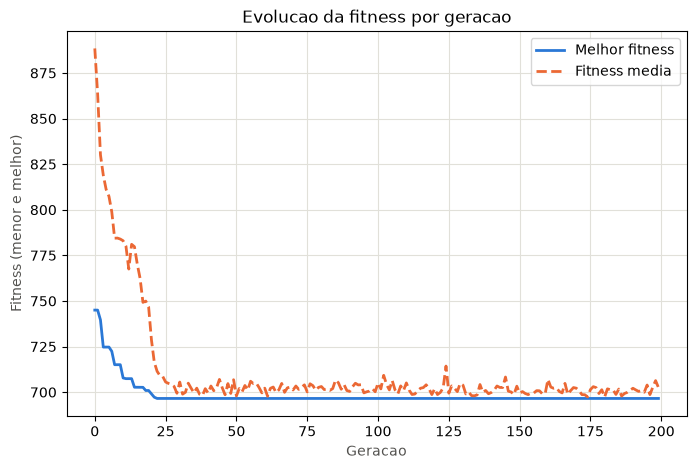

In [7]:
plot_fitness_evolution(evolution)

<Axes: title={'center': 'Rota final (origem, hospitais por prioridade e abastecimentos)'}, xlabel='Longitude', ylabel='Latitude'>

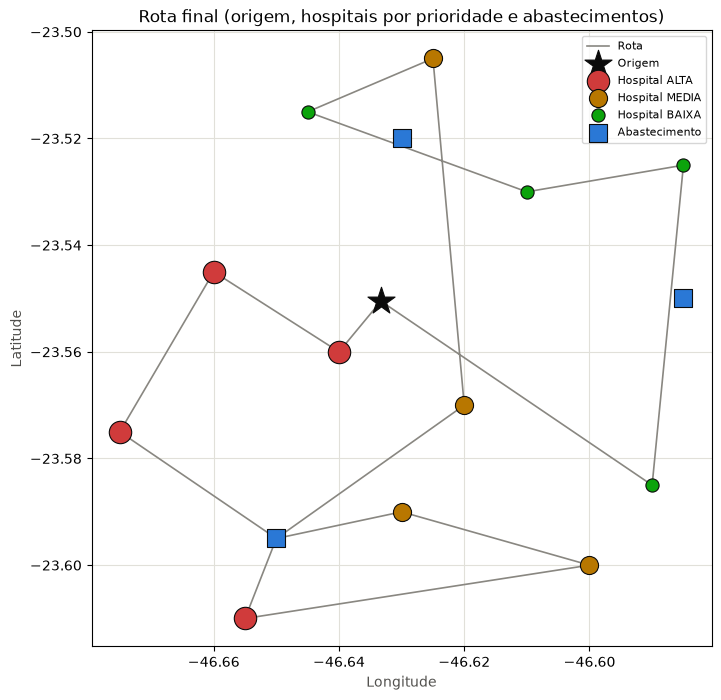

In [8]:
plot_route_map(points, best.decoded_route)

## 7. Experimentos e comparacao

Aqui rodamos os tres experimentos do plano — **E1** (50/100/5%), **E2** (100/200/10%) e **E3** (200/300/15%) — com seed fixa, comparando a rota aleatoria, o nearest neighbor e o algoritmo genetico.

Para cada metodo coletamos distancia, reabastecimentos, posicao media dos hospitais ALTA (`PosCrit`), fitness e tempo, alem do ganho percentual do GA sobre cada baseline.

In [9]:
from src.experiments import run_all_experiments, format_comparison_table

# roda E1, E2 e E3 com seed fixa e compara aleatoria x nearest neighbor x GA
experiment_results = run_all_experiments(points, distance_matrix, DEFAULT_CONFIG, seed=42)
print(format_comparison_table(experiment_results))

Exp Metodo                Dist(km)  Reab  PosCrit   Fitness  Tempo(s)
---------------------------------------------------------------------
E1 (pop=50, ger=100, mut=5%)
    Aleatoria                94.94     3     7.25    969.94     0.000
    Nearest neighbor         52.04     2     8.50    887.04     0.000
    Algoritmo genetico       60.03     2     2.50    700.03     0.151
    Ganho GA vs aleatoria:  27.8%  |  vs nearest neighbor:  21.1%

E2 (pop=100, ger=200, mut=10%)
    Aleatoria                94.94     3     7.25    969.94     0.000
    Nearest neighbor         52.04     2     8.50    887.04     0.000
    Algoritmo genetico       56.55     2     2.50    696.55     0.612
    Ganho GA vs aleatoria:  28.2%  |  vs nearest neighbor:  21.5%

E3 (pop=200, ger=300, mut=15%)
    Aleatoria                94.94     3     7.25    969.94     0.000
    Nearest neighbor         52.04     2     8.50    887.04     0.000
    Algoritmo genetico       56.16     2     2.50    696.16     1.825
    G

## 8. Relatorio em linguagem natural

A ultima etapa transforma o resultado do algoritmo em um relatorio para gestores. O payload serializado da melhor rota alimenta duas opcoes de geracao:

- um **template deterministico**, que sempre funciona (offline, sem chave de API);
- a **LLM (Claude)**, opcional, que explica o mesmo payload em linguagem natural.

Em ambos os casos a LLM apenas *explica* a rota ja calculada pelo algoritmo genetico; ela nao decide nem altera a rota.

In [10]:
from src.llm_report import build_route_payload, generate_report

# reaproveita 'best' (melhor individuo do GA) e 'points' das secoes anteriores
payload = build_route_payload(best, points, DEFAULT_CONFIG)

# Relatorio deterministico: sempre funciona, sem depender de rede ou chave
print(generate_report(payload))

RELATORIO DA ROTA DE DISTRIBUICAO MEDICA

Capacidade do veiculo: 100
Distancia total: 56.55 km
Reabastecimentos: 2
Fitness final: 696.55
Rota valida.

Hospitais de prioridade ALTA atendidos: Unidade Hospitalar A (posicao 1), Unidade Hospitalar D (posicao 2), Unidade Hospitalar G (posicao 3), Unidade Hospitalar J (posicao 4).
Paradas de reabastecimento: Abastecimento Sul, Abastecimento Sul.

Sequencia de visita:
Hospital Central -> Unidade Hospitalar A -> Unidade Hospitalar D -> Unidade Hospitalar G -> Abastecimento Sul -> Unidade Hospitalar J -> Unidade Hospitalar H -> Unidade Hospitalar E -> Abastecimento Sul -> Unidade Hospitalar B -> Unidade Hospitalar K -> Unidade Hospitalar F -> Unidade Hospitalar C -> Unidade Hospitalar I -> Unidade Hospitalar L -> Hospital Central


### Relatorio via LLM (opcional)

Requer `pip install anthropic` e a variavel de ambiente `ANTHROPIC_API_KEY`. Sem a chave, a celula abaixo apenas avisa e o relatorio deterministico acima continua valendo.

In [11]:
import os

# Requer: pip install anthropic e a variavel de ambiente ANTHROPIC_API_KEY.
# A LLM apenas explica a rota ja calculada (nao decide nem altera a rota).
if os.environ.get("ANTHROPIC_API_KEY"):
    try:
        print(generate_report(payload, use_llm=True))
    except Exception as erro:
        print(f"Falha ao chamar a LLM: {erro}")
        print("\nMantendo o relatorio deterministico exibido acima.")
else:
    print("ANTHROPIC_API_KEY nao definida - pulei a chamada a LLM.")
    print("Defina a chave e rode novamente esta celula para gerar o relatorio via Claude.")

ANTHROPIC_API_KEY nao definida - pulei a chamada a LLM.
Defina a chave e rode novamente esta celula para gerar o relatorio via Claude.
